First 5 Records:
    Order_ID       Date     Customer_Name Region     Product  Quantity  Amount
0  ORD000001 2024-09-27      Erin English   East      Laptop         7    4921
1  ORD000002 2025-04-24  Melissa Schwartz  South      Mobile         9  148041
2  ORD000003 2024-10-26     Paul Reynolds  North      Laptop        10  181170
3  ORD000004 2024-06-29       Megan Berry   West     Printer         2   79728
4  ORD000005 2024-02-10        Amber Hall   East  Headphones         4  162796

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Order_ID       100000 non-null  object        
 1   Date           100000 non-null  datetime64[ns]
 2   Customer_Name  100000 non-null  object        
 3   Region         100000 non-null  object        
 4   Product        100000 non-null  object        
 5   Quantity       1

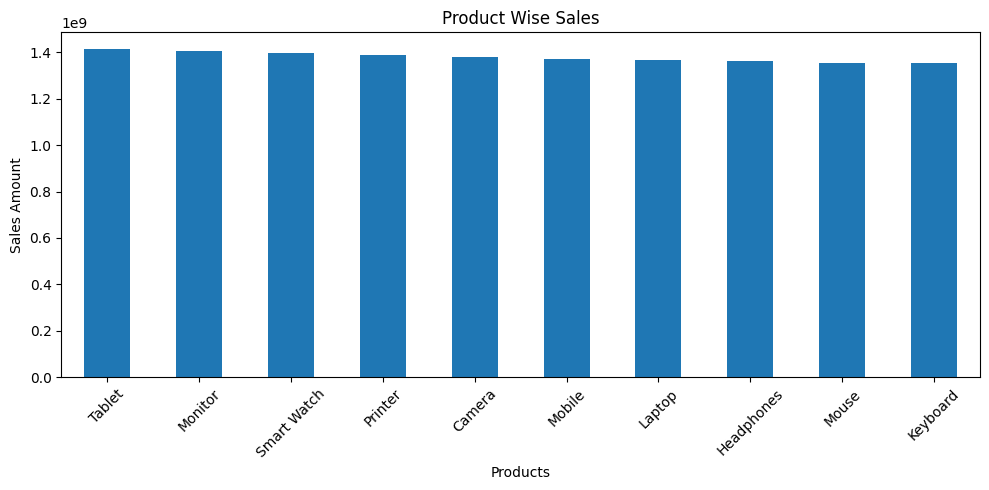

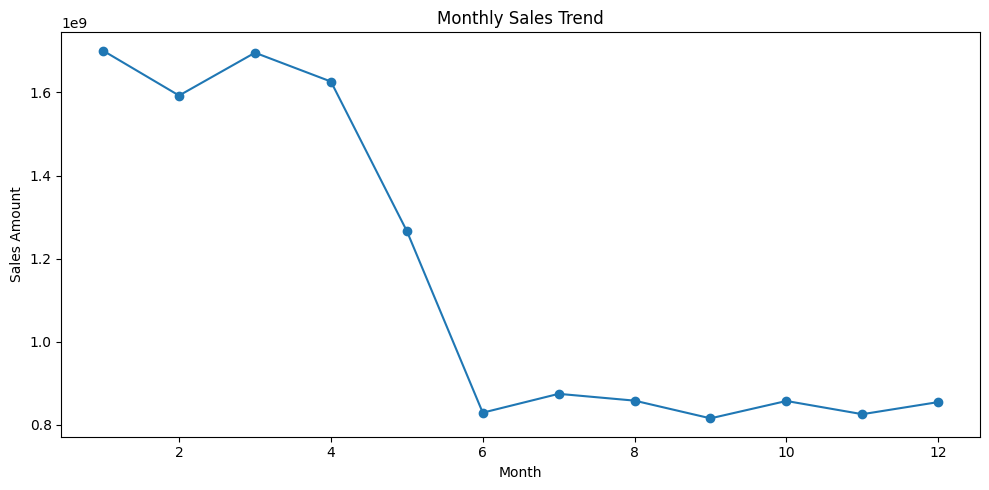

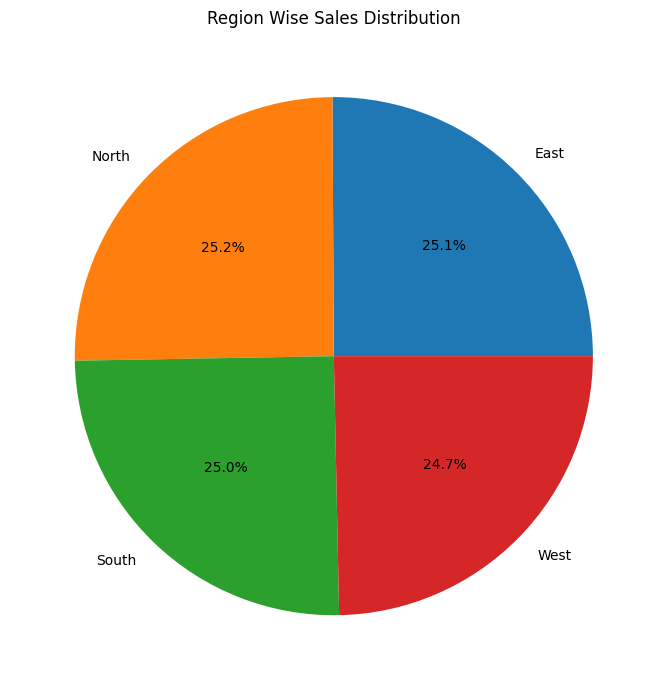

In [11]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Excel File
sales_data = pd.read_excel('/content/sales_data_100k.xlsx')

# Display First 5 Records
print("First 5 Records:")
print(sales_data.head())

# Dataset Information
print("\nDataset Info:")
print(sales_data.info())

# Remove Null Values
sales_data.dropna(inplace=True)

# Convert Date Column into Datetime Format
sales_data['Date'] = pd.to_datetime(sales_data['Date'])

# ---------------- TOTAL SALES ----------------
print("\nTotal Sales:")
print(sales_data['Amount'].sum())

# ---------------- AVERAGE SALES ----------------
print("\nAverage Sales:")
print(sales_data['Amount'].mean())

# ---------------- MAXIMUM SALES ----------------
print("\nMaximum Sales:")
print(sales_data['Amount'].max())

# ---------------- MINIMUM SALES ----------------
print("\nMinimum Sales:")
print(sales_data['Amount'].min())

# ---------------- PRODUCT WISE SALES ----------------
product_sales = sales_data.groupby('Product')['Amount'].sum()

print("\nProduct Wise Sales:")
print(product_sales)

# ---------------- REGION WISE SALES ----------------
region_sales = sales_data.groupby('Region')['Amount'].sum()

print("\nRegion Wise Sales:")
print(region_sales)

# ---------------- BAR GRAPH ----------------
plt.figure(figsize=(10,5))

product_sales.sort_values(ascending=False).plot(kind='bar')

plt.title('Product Wise Sales')
plt.xlabel('Products')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ---------------- LINE CHART ----------------
monthly_sales = sales_data.groupby(
    sales_data['Date'].dt.month
)['Amount'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales Amount')

plt.tight_layout()
plt.show()

# ---------------- PIE CHART ----------------
plt.figure(figsize=(7,7))

region_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Region Wise Sales Distribution')
plt.ylabel('')

plt.tight_layout()
plt.show()